In [1]:
import os
import json

from glob import glob

import climlab
import torch
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd

import tephi

/gws/ssde/j25a/ai4er/users/pn341/opt/miniconda3/envs/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = "/gws/ssde/j25a/ai4er/users/pn341/climate-rl-cc"
RECORDS_DIR = f"{BASE_DIR}/records"
DATASETS_DIR = f"{BASE_DIR}/datasets"
IMGS_DIR = f"{BASE_DIR}/results/imgs"
PLOTTING_DATA_DIR = f"{BASE_DIR}/results/data"

EXP_ID = "rce17-v0-cc"

NUM_STEPS = 500

DELTA_SST = 4.0

In [3]:
fp_air = f"{DATASETS_DIR}/air.mon.ltm.1981-2010.nc"
ncep_url = "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/"


def download_and_save_dataset(url, filepath, dataset_name):
    if not os.path.exists(filepath):
        print(f"Downloading {dataset_name} data ...")
        dataset = xr.open_dataset(
            url,
            decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
        )
        dataset.to_netcdf(filepath)
        print(f"{dataset_name} data saved to {filepath}")
    else:
        print(f"Loading {dataset_name} data ...")
        dataset = xr.open_dataset(
            filepath,
            decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
        )
    return dataset


ncep_air = download_and_save_dataset(
    ncep_url + "pressure/air.mon.1981-2010.ltm.nc#mode=bytes",
    fp_air,
    "NCEP pressure-level temperature",
)

coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim="lat")
Tobs = (ncep_air.air * weight).mean(dim=("lat", "lon", "time"))

Loading NCEP pressure-level temperature data ...


In [4]:
rce_state = climlab.column_state(lev=Tobs.level[1:], water_depth=2.5)
h2o = climlab.radiation.ManabeWaterVapor(
    state=rce_state,
    lev=Tobs.level[1:],
)
rad = climlab.radiation.RRTMG(
    name="Radiation (net)",
    state=rce_state,
    specific_humidity=h2o.q,
    S0=1365.0,
    timestep=climlab.constants.seconds_per_day,
    albedo=0.25,
)
conv = climlab.convection.ConvectiveAdjustment(
    name="Convection",
    state=rce_state,
    adj_lapse_rate="MALR",
    timestep=rad.timestep,
)

baseline_rcm = climlab.couple([rad, conv], name="Baseline (no CC, no RL)")
baseline_rcm.state.Tatm[:] = baseline_rcm.state.Ts

cc_rcm = climlab.process_like(baseline_rcm)
cc_rcm.name = "CC (no RL)"

# Apply SST forcing
forced_ts = np.array(baseline_rcm.state.Ts, dtype=np.float32) + DELTA_SST
cc_rcm.state.Ts[:] = forced_ts

In [5]:
for i in range(NUM_STEPS):
    baseline_rcm.step_forward()    
    cc_rcm.step_forward()
    forced_ts = np.array(baseline_rcm.state.Ts, dtype=np.float32) + DELTA_SST
    cc_rcm.state.Ts[:] = forced_ts

In [6]:
def fetch_last_state(delta_sst, last_step=500):
    try:
        record_fn = glob(f"{RECORDS_DIR}/rce17-v0-cc_delta_sst-{delta_sst}_*/step_{last_step}.pth")[0]
        with open(record_fn, "rb") as f:
            record = torch.load(f)
            rce_state = record["next_obs"][-1]
        return rce_state
    except IndexError:
        print(f"No records found for delta_sst={delta_sst} at step {last_step}")
        return None

rl_nocc_profile = fetch_last_state(delta_sst=0.0)
cc_rl_profile = fetch_last_state(delta_sst=DELTA_SST)

/work/scratch-nopw2/pn341/tmp/ipykernel_3001684/4047058572.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  record = torch.load(f)


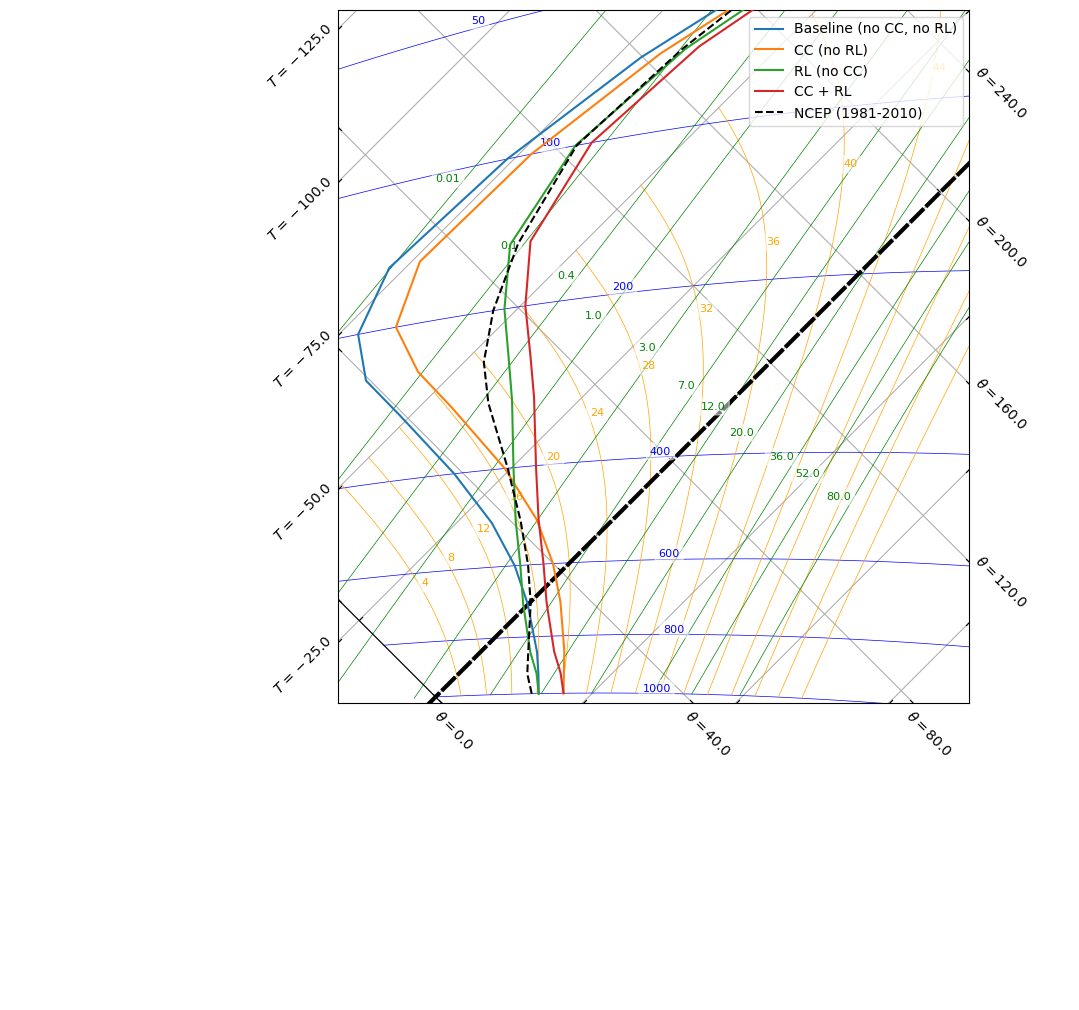

In [7]:
def _get_tephigram_data(rcm):
    """Build pressure-temperature pairs used by tephi plotting.

    Parameters
    ----------
    rcm : climlab process
        Model process to convert to plotting data.

    Returns
    -------
    numpy.ndarray
        Two-column array of [pressure_hPa, temperature_C].
    """
    temp = np.concatenate([rcm.Tatm, rcm.Ts], dtype=np.float32)
    temp -= climlab.constants.tempCtoK
    levels = np.concatenate([rcm.lev, [1000]], dtype=np.float32)

    df = pd.DataFrame(zip(levels, temp))
    df.columns = ["pressure", "temperature"]
    return df.values

pressure_levels = np.concatenate([baseline_rcm.lev, [1000]], dtype=np.float32)

fig = plt.figure(figsize=(9, 9))

tephi.ISOBAR_FIXED = [50, 1000, 100]
tpg = tephi.Tephigram(
    figure=fig,
    anchor=[(1000, -15), (70, -25)],
)
tpg.plot(
    _get_tephigram_data(baseline_rcm),
    label=baseline_rcm.name,
    color="tab:blue",
)
tpg.plot(
    _get_tephigram_data(cc_rcm),
    label=cc_rcm.name,
    color="tab:orange",
)

tpg.plot(
    list(zip(pressure_levels, rl_nocc_profile)),
    label="RL (no CC)",
    color="tab:green",
)

tpg.plot(
    list(zip(pressure_levels, cc_rl_profile)),
    label="CC + RL",
    color="tab:red",
)

tpg.plot(
    list(zip(Tobs.level.values, Tobs.values)),
    label="NCEP (1981-2010)",
    color="black",
    linestyle="--",
)

tpg.axes.legend(loc="upper right")
tpg.axes.set_axis_off()

baseline_profile = (
    np.concatenate([baseline_rcm.Tatm, baseline_rcm.Ts], dtype=np.float32)
    - climlab.constants.tempCtoK
)
cc_profile = (
    np.concatenate([cc_rcm.Tatm, cc_rcm.Ts], dtype=np.float32)
    - climlab.constants.tempCtoK
)

plotting_data = {
    "pressure": Tobs.level.values.reshape(-1).tolist(),
    "baseline": baseline_profile.reshape(-1).tolist(),
    "cc_no_rl": cc_profile.reshape(-1).tolist(),
    "rl_nocc": rl_nocc_profile.reshape(-1).tolist(),
    "cc_rl": cc_rl_profile.reshape(-1).tolist(),
    "ncep": Tobs.values.reshape(-1).tolist(),
}

# Save plots and data
for ext in ["pdf", "png"]:
    plt.savefig(
        f"{IMGS_DIR}/{ext}/{EXP_ID}_delta_sst-{DELTA_SST}_temp_profile.{ext}",
        dpi=300,
        bbox_inches="tight",
    )

plotting_data_path = (
    f"{PLOTTING_DATA_DIR}/{EXP_ID}_delta_sst-{DELTA_SST}_temp_profile.json"
)
with open(plotting_data_path, "w", encoding="utf-8") as fh:
    json.dump(plotting_data, fh, indent=4)
